# Importing Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# %matplotlib.inline


# Load the data and inspect the data

In [2]:
# load the data
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")


In [7]:
# inspect the data

# size of the data
print(df.shape)
#  check the top of the dataset
df.head()

(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# check bottom of the dataset
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [6]:
# check the datatypes
df.dtypes

,0
total_bill,float64
tip,float64
sex,object
smoker,object
day,object
time,object
size,int64


In [8]:
# check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


There are 244 rows and 7 columns of non-null data, with total_bill, tip as float datatypes and sex, smoker, day and time as string objects and size is an integer.

In [9]:
# quick dataset description
df.describe(include='all')

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


# Data Cleaning and Preparation

In [10]:
# check for missing values
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


There are no missing values in the dataset.

In [13]:
# check for duplicate entries
print(df.duplicated().sum())

# check the duplicated entry
df[df.duplicated()]

,total_bill,tip,sex,smoker,day,time,size
202,13.0,2.0,Female,Yes,Thur,Lunch,2


> Since there is no unique ID to distinguish the duplicate entries, it is best to retain it rather than remove it.

Check for outliers in numeric columns

In [14]:
# check for outliers in numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col}:")
    print(outliers)
    print("\n")


Outliers in total_bill:
     total_bill    tip     sex smoker   day    time  size
59        48.27   6.73    Male     No   Sat  Dinner     4
102       44.30   2.50  Female    Yes   Sat  Dinner     3
142       41.19   5.00    Male     No  Thur   Lunch     5
156       48.17   5.00    Male     No   Sun  Dinner     6
170       50.81  10.00    Male    Yes   Sat  Dinner     3
182       45.35   3.50    Male    Yes   Sun  Dinner     3
184       40.55   3.00    Male    Yes   Sun  Dinner     2
197       43.11   5.00  Female    Yes  Thur   Lunch     4
212       48.33   9.00    Male     No   Sat  Dinner     4


Outliers in tip:
     total_bill    tip     sex smoker   day    time  size
23        39.42   7.58    Male     No   Sat  Dinner     4
47        32.40   6.00    Male     No   Sun  Dinner     4
59        48.27   6.73    Male     No   Sat  Dinner     4
141       34.30   6.70    Male     No  Thur   Lunch     6
170       50.81  10.00    Male    Yes   Sat  Dinner     3
183       23.17   6.50    Mal

There are a few outliers in the numeric fields: total_bill, tip and size. Since the data is quite small, it is not best to remove the outliers because the dataset will become even smaller for training purposes.

# Exploratory Data Analysis

**Univariate Analysis**

In [28]:
print(df.columns)
columns_dict = {'total_bill':1, 'tip':2, 'sex':3, 'smoker':4, 'day':5, 'time':6, 'size':7}

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


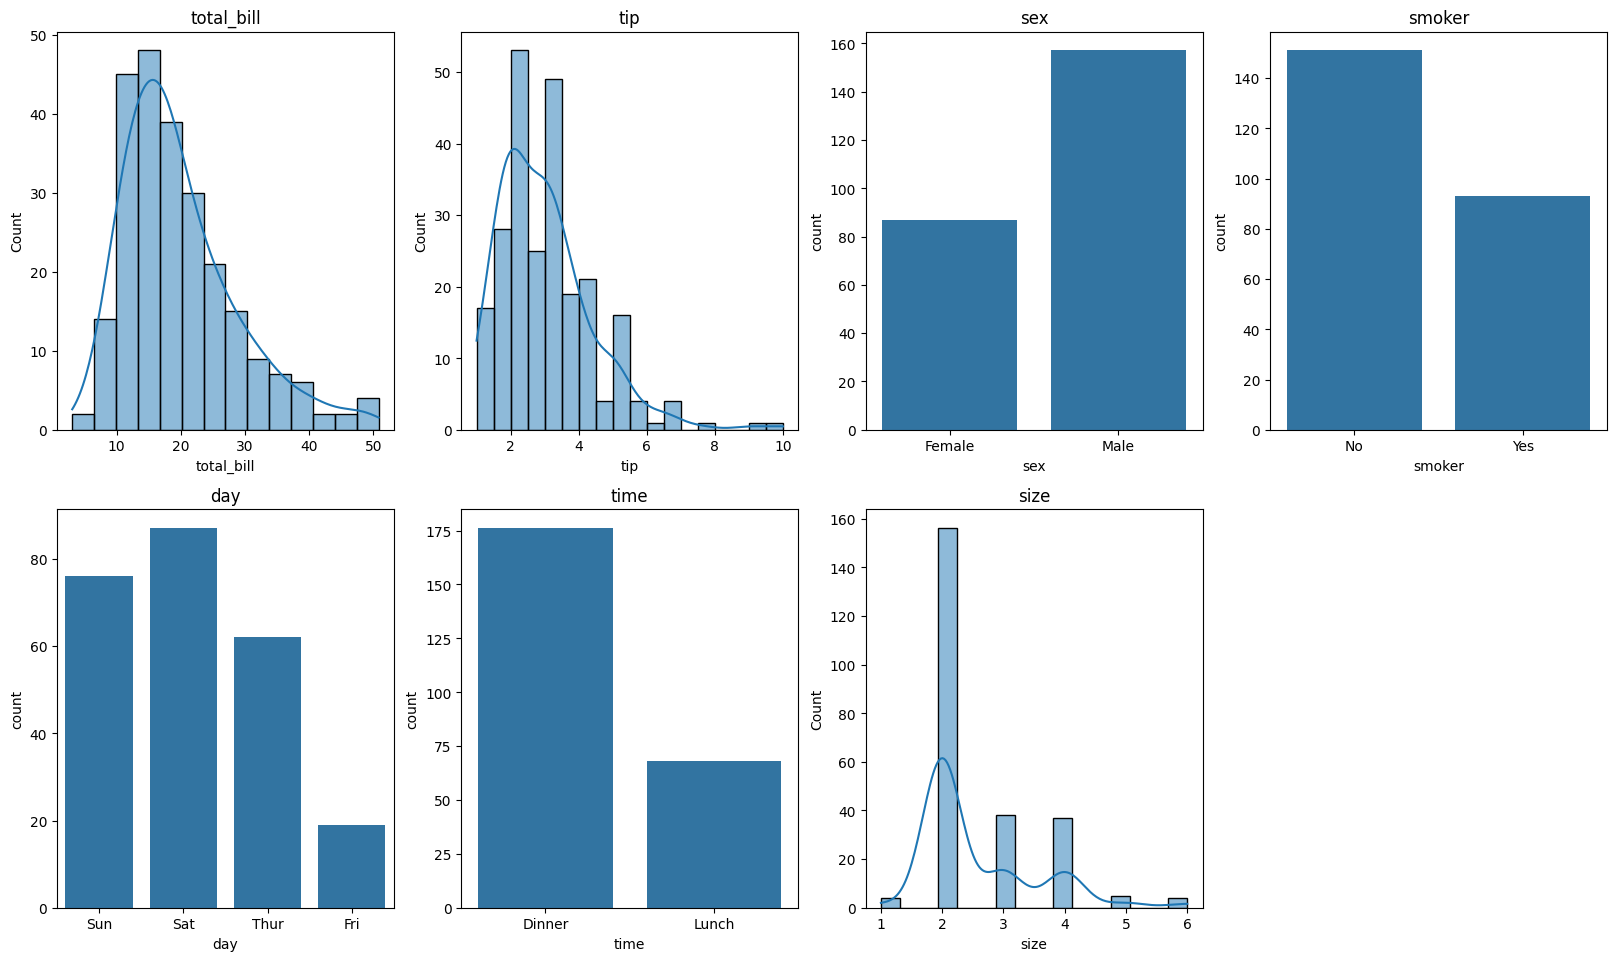

In [30]:
# distribution plots of the data
plt.figure(figsize=(20,30))
for variable, i in columns_dict.items():
    plt.subplot(5, 4, i)
    if df[variable].dtype == 'object':
        sns.countplot(x=variable, data=df)
    else:
        sns.histplot(df[variable], kde=True)
    plt.title(variable)

plt.show()

- There seems to be an imbalance in the gender, smoker and time of day.
- The total bill and tip are skewed to the right.

Mean, median and Mode

In [31]:
# mean, median, mode for all columns
for variable in columns_dict:
    print(variable)
    print('  mean:  ', df[variable].mean() if df[variable].dtype != 'object' else 'n/a')
    print('  median:', df[variable].median() if df[variable].dtype != 'object' else 'n/a')
    print('  mode:  ', df[variable].mode()[0])

total_bill
  mean:   19.78594262295082
  median: 17.795
  mode:   13.42
tip
  mean:   2.99827868852459
  median: 2.9
  mode:   2.0
sex
  mean:   n/a
  median: n/a
  mode:   Male
smoker
  mean:   n/a
  median: n/a
  mode:   No
day
  mean:   n/a
  median: n/a
  mode:   Sat
time
  mean:   n/a
  median: n/a
  mode:   Dinner
size
  mean:   2.569672131147541
  median: 2.0
  mode:   2


## Bivariate analysis

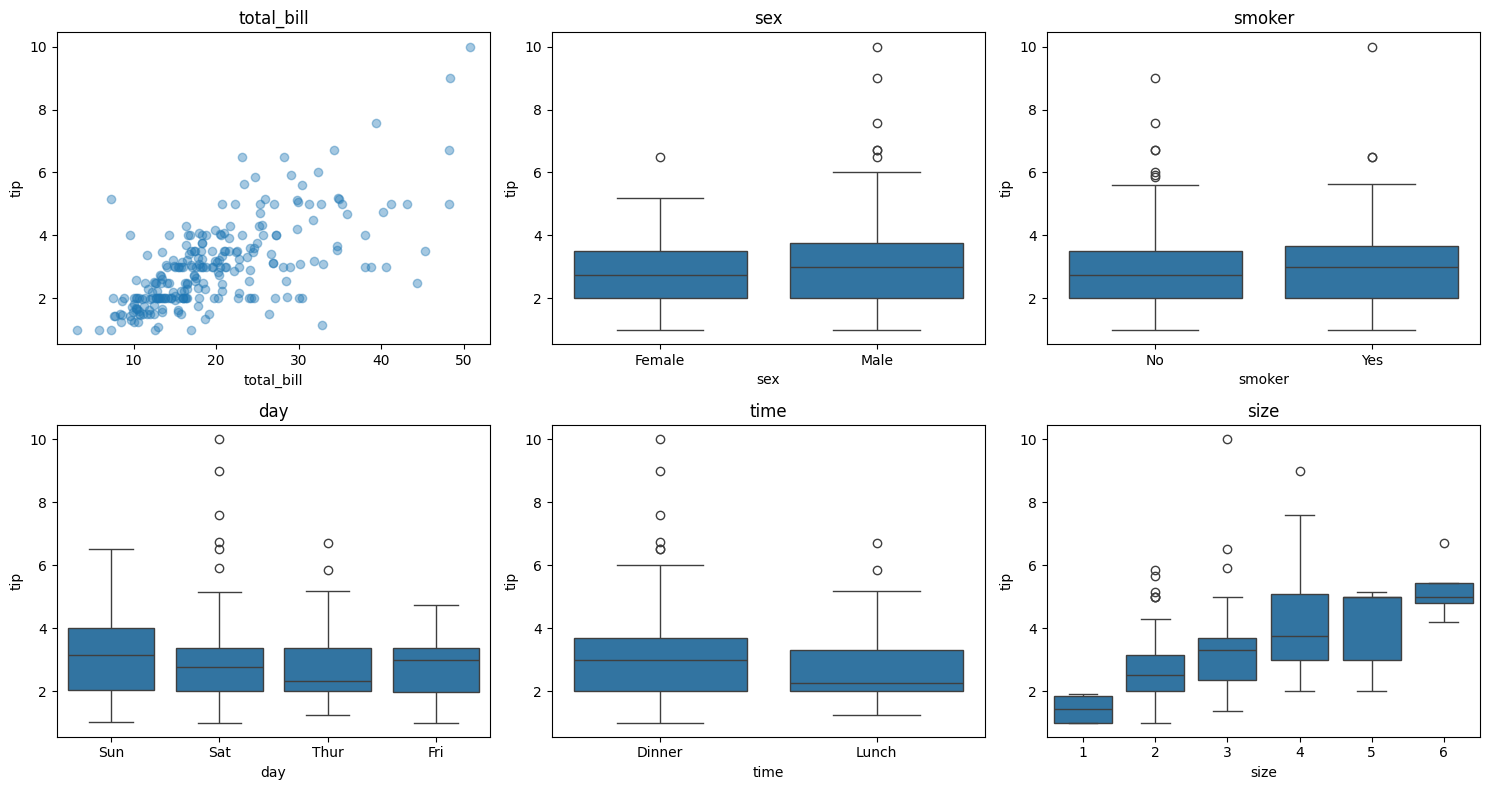

In [36]:
target = 'tip'
cols = [c for c in df.columns if c != target]   # 6 predictors excludes tip

plt.figure(figsize=(15,8))
for i, variable in enumerate(cols, start=1):
    plt.subplot(2, 3, i)
    if df[variable].nunique() < 15:
        sns.boxplot(x=variable, y=target, data=df)
    else:
        plt.scatter(df[variable], df[target], marker='o', alpha=0.4)
    plt.title(variable)
    plt.xlabel(variable)
    plt.ylabel(target)

plt.tight_layout()
plt.show()

There seems to be a positive correlation between the total bill and tip

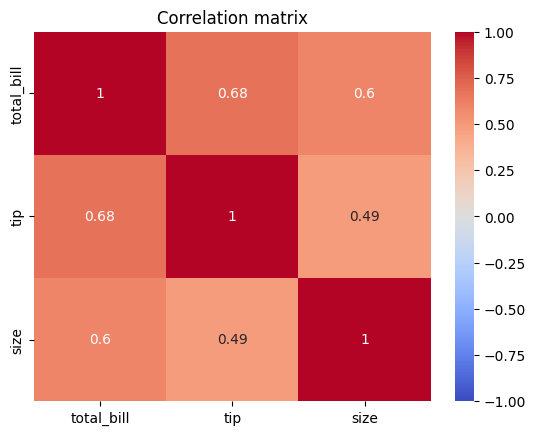

In [37]:
# correlation matrix

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.show()

# Encoding the features

In [38]:
# convert categorical features to numerical
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'day', 'time'])
df_encoded.head()

,total_bill,tip,size,sex_Female,sex_Male,smoker_No,smoker_Yes,day_Fri,day_Sat,day_Sun,day_Thur,time_Dinner,time_Lunch
0,16.99,1.01,2,True,False,True,False,False,False,True,False,True,False
1,10.34,1.66,3,False,True,True,False,False,False,True,False,True,False
2,21.01,3.50,3,False,True,True,False,False,False,True,False,True,False
3,23.68,3.31,2,False,True,True,False,False,False,True,False,True,False
4,24.59,3.61,4,True,False,True,False,False,False,True,False,True,False


# Modeling

In [39]:
# prepare the data for modeling
X = df_encoded.drop('tip', axis=1)
y = df_encoded['tip']

In [40]:
# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [44]:
# simple regression model to predict tip
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [45]:
# make predictions on the test set
y_pred = model.predict(X_test)

In [47]:
# Model performance
print("Model Performance: ")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Model Performance: 
Root Mean Squared Error (RMSE): 0.93
R-squared (R²): 0.35


In [57]:
# print model coefficients in descending order
coefficients = model.coef_
feature_names = X.columns
coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coefficients_df = coefficients_df.sort_values(by='Coefficient', ascending=False)
coefficients_df

,Feature,Coefficient
1,size,0.206576
4,smoker_No,0.140592
6,day_Fri,0.118361
0,total_bill,0.100555
11,time_Lunch,0.092742
3,sex_Male,0.013771
8,day_Sun,0.008142
2,sex_Female,-0.013771
7,day_Sat,-0.024573
10,time_Dinner,-0.092742


/tmp/ipykernel_1174/4268850102.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefficients_df, palette='viridis',legend=False)


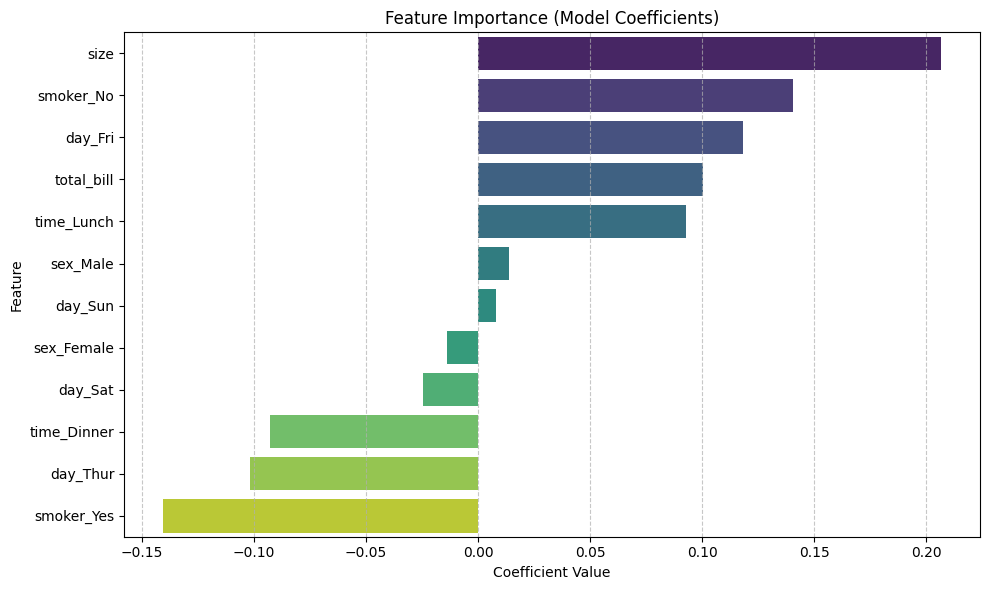

<Figure size 640x480 with 0 Axes>

In [59]:
# Display coefficients to understand feature influence

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients_df, palette='viridis',legend=False)
plt.title('Feature Importance (Model Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# save the bar plot to a .png file
plt.savefig('feature_importance.png')


- Size is the most influential variable. For every additional person, the predicted tip increases by about 0.20.
- Smoker_No(coef 0.14) - Non-smokers generally tip slightly more than smokers.
- day_Fri(coef 0.11) - Fridays are also associated with higher tips compared to other days.
- total_bill - as the total bill rises, so does the amount paid in tips.
- time_Lunch - lunch hour of the day is also associated with higher tips compared to dinner time.
- Sex_Male - Males are predicted to also tip slightly more than females.




In [50]:
conv